# Survey Analysis (§5.5)

Loads `data/eval/survey_responses.xlsx` (anonymised Microsoft Forms export, n=10) and produces:

- Per-question counts (Q1–Q11) printed for paste into the §5.5 / §5.3.2 / §5.6.3 prose
- Q5 / Q6 sub-row × band counts (the matrix questions that the PDF summary did not extract)
- Q4 / Q8 / Q10 / Q11 full free-text with simple keyword-based theme tags
- Two figures into `Report/figures/evaluation/`:
  - `fig:eval-survey-likert` — Q3 + Q7 + Q9 horizontal bar chart
  - `fig:eval-survey-clarity-intuitiveness` — Q5 + Q6 stacked bars
- A canonical `data/eval/survey_summary.json` that downstream prose / writing chat can lift from

Run all cells in order. No external dependencies beyond pandas, matplotlib, and openpyxl.

In [1]:
from __future__ import annotations

import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
XLSX_PATH = REPO_ROOT / "data" / "eval" / "survey_responses.xlsx"
SUMMARY_PATH = REPO_ROOT / "data" / "eval" / "survey_summary.json"
FIG_DIR = REPO_ROOT / "Report" / "figures" / "evaluation"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_excel(XLSX_PATH)
N = len(df)
print(f"Loaded {N} responses, {len(df.columns)} columns")
print(f"Columns: {list(df.columns)}")

Loaded 10 responses, 19 columns
Columns: ['ID', 'Start time', 'Completion time', 'Email', 'Name', 'Last modified time', 'What best describes you?', 'In your experience, how often do students who need help in a lab session actually receive it in time?', 'How easy is it for staff to identify which students are struggling in a typical lab.', 'What do you think is the biggest barrier to providing timely support to students in computer labs is?', 'Student Struggle', 'Question Difficulty', 'Student Struggle Bands', 'Question Difficulty Bands', 'How likely would you be to trust the dashboard when determining what student is struggling the most and what question is the most difficult.', 'What concerns, if any, would you have about using a system like this in a real lab?', 'The dashboard surfaces a per-student struggle score to instructors. If you were the student being scored, how comfortable would you be with this?', 'Any ethical, privacy, or fairness concerns you would want addressed before 

## Likert scales — canonical order

Defined up-front so counts and figures use the same band ordering.

In [2]:
Q1_ORDER = [
    "Undergraduate Student",
    "Postgraduate Taught Student",
    "Postgraduate Research Student",
    "Staff",
    "Other",
]
Q2_ORDER = ["Always", "Often", "Sometimes", "Rarely", "Never"]
Q3_ORDER = [
    "Extremely easy",
    "Somewhat easy",
    "Neutral",
    "Somewhat not easy",
    "Extremely not easy",
]
INTUITIVENESS_ORDER = [
    "Completely Unintuitive",
    "Slightly Unintuitive",
    "Neutral",
    "Slightly Intuitive",
    "Completely Intuitive",
]
Q7_ORDER = [
    "Very likely",
    "Somewhat likely",
    "Neither likely nor unlikely",
    "Somewhat unlikely",
    "Very unlikely",
]
Q9_ORDER = [
    "Very comfortable",
    "Somewhat comfortable",
    "Neither comfortable nor uncomfortable",
    "Somewhat uncomfortable",
    "Very uncomfortable",
]


def counts(col: pd.Series, order: list[str]) -> dict[str, int]:
    """Return ordered band → count dict, including zero-count bands."""
    raw = col.dropna().astype(str).value_counts().to_dict()
    return {band: int(raw.get(band, 0)) for band in order}

## Single-item Likert questions (Q1, Q2, Q3, Q7, Q9)

In [3]:
Q1 = counts(df["What best describes you?"], Q1_ORDER)
Q2 = counts(
    df[
        "In your experience, how often do students who need help in a lab session actually receive it in time?"
    ],
    Q2_ORDER,
)
Q3 = counts(
    df["How easy is it for staff to identify which students are struggling in a typical lab."],
    Q3_ORDER,
)
Q7 = counts(
    df[
        "How likely would you be to trust the dashboard when determining what student is struggling the most and what question is the most difficult."
    ],
    Q7_ORDER,
)
Q9 = counts(
    df[
        "The dashboard surfaces a per-student struggle score to instructors. If you were the student being scored, how comfortable would you be with this?"
    ],
    Q9_ORDER,
)

for label, c in [("Q1", Q1), ("Q2", Q2), ("Q3", Q3), ("Q7", Q7), ("Q9", Q9)]:
    total = sum(c.values())
    print(f"\n{label} (n={total}):")
    for band, n in c.items():
        pct = 100 * n / total if total else 0
        print(f"  {band:<40s} {n}  ({pct:.0f}%)")


Q1 (n=10):
  Undergraduate Student                    6  (60%)
  Postgraduate Taught Student              1  (10%)
  Postgraduate Research Student            2  (20%)
  Staff                                    1  (10%)
  Other                                    0  (0%)

Q2 (n=10):
  Always                                   1  (10%)
  Often                                    4  (40%)
  Sometimes                                4  (40%)
  Rarely                                   1  (10%)
  Never                                    0  (0%)

Q3 (n=10):
  Extremely easy                           0  (0%)
  Somewhat easy                            2  (20%)
  Neutral                                  2  (20%)
  Somewhat not easy                        4  (40%)
  Extremely not easy                       2  (20%)

Q7 (n=10):
  Very likely                              2  (20%)
  Somewhat likely                          5  (50%)
  Neither likely nor unlikely              1  (10%)
  Somewhat unlikely

## Q5 / Q6 matrix questions (per sub-row × band)

The PDF summary only showed stacked bars without exact counts for these; we recover them directly from the xlsx columns.

In [4]:
Q5_STRUGGLE = counts(df["Student Struggle"], INTUITIVENESS_ORDER)
Q5_DIFFICULTY = counts(df["Question Difficulty"], INTUITIVENESS_ORDER)
Q6_STRUGGLE_BANDS = counts(df["Student Struggle Bands"], INTUITIVENESS_ORDER)
Q6_DIFFICULTY_BANDS = counts(df["Question Difficulty Bands"], INTUITIVENESS_ORDER)

matrix_rows = [
    ("Q5 Student Struggle", Q5_STRUGGLE),
    ("Q5 Question Difficulty", Q5_DIFFICULTY),
    ("Q6 Student Struggle Bands", Q6_STRUGGLE_BANDS),
    ("Q6 Question Difficulty Bands", Q6_DIFFICULTY_BANDS),
]

print("  Sub-row                          CU  SU   N  SI  CI")
print("  " + "-" * 56)
for label, c in matrix_rows:
    cells = "  ".join(f"{c[b]:>2d}" for b in INTUITIVENESS_ORDER)
    print(f"  {label:<32s} {cells}")

  Sub-row                          CU  SU   N  SI  CI
  --------------------------------------------------------
  Q5 Student Struggle               0   1   0   2   7
  Q5 Question Difficulty            0   1   0   2   7
  Q6 Student Struggle Bands         0   1   0   3   6
  Q6 Question Difficulty Bands      0   1   0   3   6


## Persistent-dissenter check

Does the same respondent give the 'Slightly Unintuitive' rating across all four Q5/Q6 sub-rows? If so the disagreement is a single outlier, not a distributed minority — relevant for the §5.3.2 NFR2 framing.

In [5]:
mask = (
    (df["Student Struggle"] == "Slightly Unintuitive")
    & (df["Question Difficulty"] == "Slightly Unintuitive")
    & (df["Student Struggle Bands"] == "Slightly Unintuitive")
    & (df["Question Difficulty Bands"] == "Slightly Unintuitive")
)
n_same_dissenter = int(mask.sum())
print(f"Respondents who rated all four sub-rows Slightly Unintuitive: {n_same_dissenter}")
if n_same_dissenter == 1:
    idx = df.index[mask][0]
    print(f"  → single persistent dissenter at response ID {df.loc[idx, 'ID']}")

Respondents who rated all four sub-rows Slightly Unintuitive: 1
  → single persistent dissenter at response ID 3


## Free-text columns (Q4, Q8, Q10, Q11)

Themes are tagged by a simple keyword-list pass — easy to override or refine later. Each non-empty response gets one or more theme tags; counts are tallied below.

In [6]:
# Theme keyword maps. Each key is a theme; each value is a list of substrings
# that mark a response as belonging to that theme.
Q4_THEMES = {
    "Staff shortage": ["not enough staff", "lack of staff", "not enough time", "don't engage"],
    "Identifying student need": ["identifying", "recognise", "recognize", "hard to see"],
    "Help-seeking reluctance": ["shy", "not be willing to ask", "asking for help", "personality", "not confident"],
}
Q8_THEMES = {
    "Surveillance discomfort": ["pressure", "monitored", "tracked", "surveyed", "public"],
    "Quantifiability limits": ["unquantifiable", "hard to quantify", "human factors"],
}
Q10_THEMES = {
    "Name visibility / re-identification": ["name", "student id", "connection"],
    "Consent and transparency": ["aware", "participation", "adoption"],
    "Lecturer bias on grading": ["coursework", "exam", "grade"],
    "Data-use scope": ["university data", "data be used"],
}
Q11_THEMES = {
    "Cross-session aggregation": ["across labs", "frequently"],
    "Criteria transparency": ["criteria", "based on"],
}

FREE_TEXT_COLS = {
    "Q4": (
        "What do you think is the biggest barrier to providing timely support to students in computer labs is?",
        Q4_THEMES,
    ),
    "Q8": (
        "What concerns, if any, would you have about using a system like this in a real lab?",
        Q8_THEMES,
    ),
    "Q10": (
        "Any ethical, privacy, or fairness concerns you would want addressed before adoption?",
        Q10_THEMES,
    ),
    "Q11": (
        "If there is one thing you would change about the dashboard, what would it be?",
        Q11_THEMES,
    ),
}


def tag_themes(text: str, themes: dict[str, list[str]]) -> list[str]:
    tl = text.lower()
    return [name for name, kws in themes.items() if any(kw in tl for kw in kws)]


freetext_summary: dict[str, dict] = {}
for qid, (col, theme_map) in FREE_TEXT_COLS.items():
    responses = df[col].dropna().astype(str).tolist()
    responses = [r for r in responses if r.strip() and r.strip() != "-"]
    tagged = [(r, tag_themes(r, theme_map)) for r in responses]
    theme_counts = Counter(t for _, ts in tagged for t in ts)
    untagged = [r for r, ts in tagged if not ts]
    freetext_summary[qid] = {
        "n_responses": len(responses),
        "responses": responses,
        "theme_counts": dict(theme_counts),
        "untagged": untagged,
    }
    print(f"\n{qid} ({len(responses)} substantive responses):")
    for theme, n in theme_counts.most_common():
        print(f"  {theme}: {n}")
    if untagged:
        print(f"  [untagged]: {len(untagged)} response(s) — review keyword map")
        for r in untagged:
            print(f"    • {r}")


Q4 (9 substantive responses):
  Staff shortage: 4
  Identifying student need: 3
  Help-seeking reluctance: 3

Q8 (5 substantive responses):
  Surveillance discomfort: 3
  Quantifiability limits: 2

Q10 (5 substantive responses):
  Name visibility / re-identification: 2
  Consent and transparency: 1
  Lecturer bias on grading: 1
  Data-use scope: 1
  [untagged]: 1 response(s) — review keyword map
    • Some students may not be comfortable with question 9

Q11 (2 substantive responses):
  Cross-session aggregation: 1
  Criteria transparency: 1


## Figure: `fig:eval-survey-likert` (Q3 + Q7 + Q9 horizontal stacked bars)

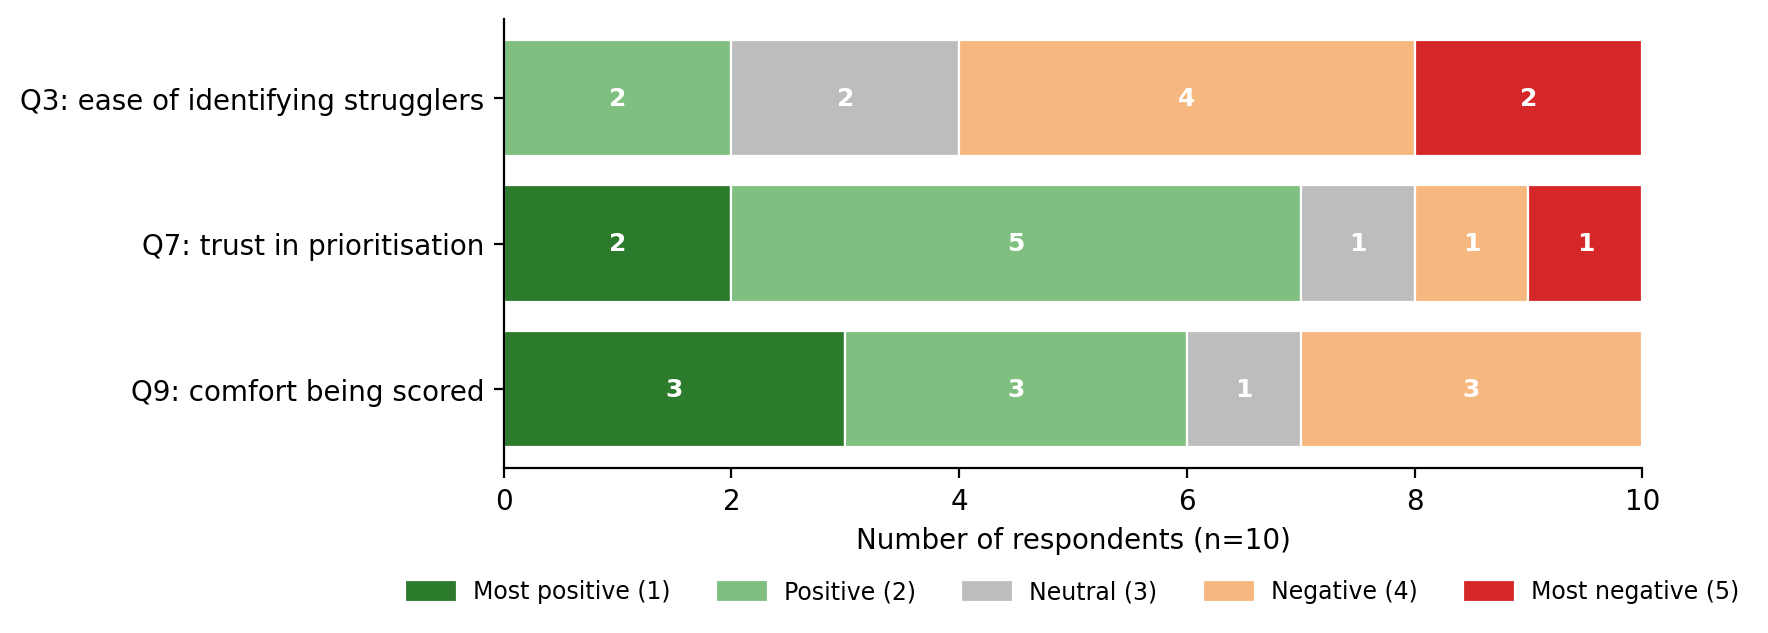

saved c:\Users\Bakri\OneDrive - Loughborough University\Masters Year\Thesis\Dashboard v3\Report\figures\evaluation\eval-survey-likert.png


In [7]:
DIVERGING_PALETTE = ["#2c7a2c", "#7fbf7f", "#bdbdbd", "#f7b87f", "#d62728"]

likert_rows = [
    ("Q3: ease of identifying strugglers", list(Q3.values()), list(Q3.keys())),
    ("Q7: trust in prioritisation", list(Q7.values()), list(Q7.keys())),
    ("Q9: comfort being scored", list(Q9.values()), list(Q9.keys())),
]

fig, ax = plt.subplots(figsize=(8.5, 3.4), dpi=200)
for i, (label, vals, bands) in enumerate(likert_rows):
    left = 0
    for v, band, colour in zip(vals, bands, DIVERGING_PALETTE):
        if v == 0:
            left += v
            continue
        ax.barh(i, v, left=left, color=colour, edgecolor="white", linewidth=0.8)
        if v >= 1:
            ax.text(left + v / 2, i, str(v), ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
        left += v

ax.set_yticks(range(len(likert_rows)))
ax.set_yticklabels([r[0] for r in likert_rows])
ax.invert_yaxis()
ax.set_xlim(0, N)
ax.set_xlabel(f"Number of respondents (n={N})")
ax.spines[["top", "right"]].set_visible(False)

# Build a legend from Q7 ordering (5-point scale)
legend_labels = ["Most positive (1)", "Positive (2)", "Neutral (3)", "Negative (4)", "Most negative (5)"]
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in DIVERGING_PALETTE]
ax.legend(legend_handles, legend_labels, loc="lower center", bbox_to_anchor=(0.5, -0.35),
          ncol=5, frameon=False, fontsize=8.5)

plt.tight_layout()
out = FIG_DIR / "eval-survey-likert.png"
plt.savefig(out, bbox_inches="tight")
plt.show()
print(f"saved {out}")

## Figure: `fig:eval-survey-clarity-intuitiveness` (Q5 + Q6 stacked bars)

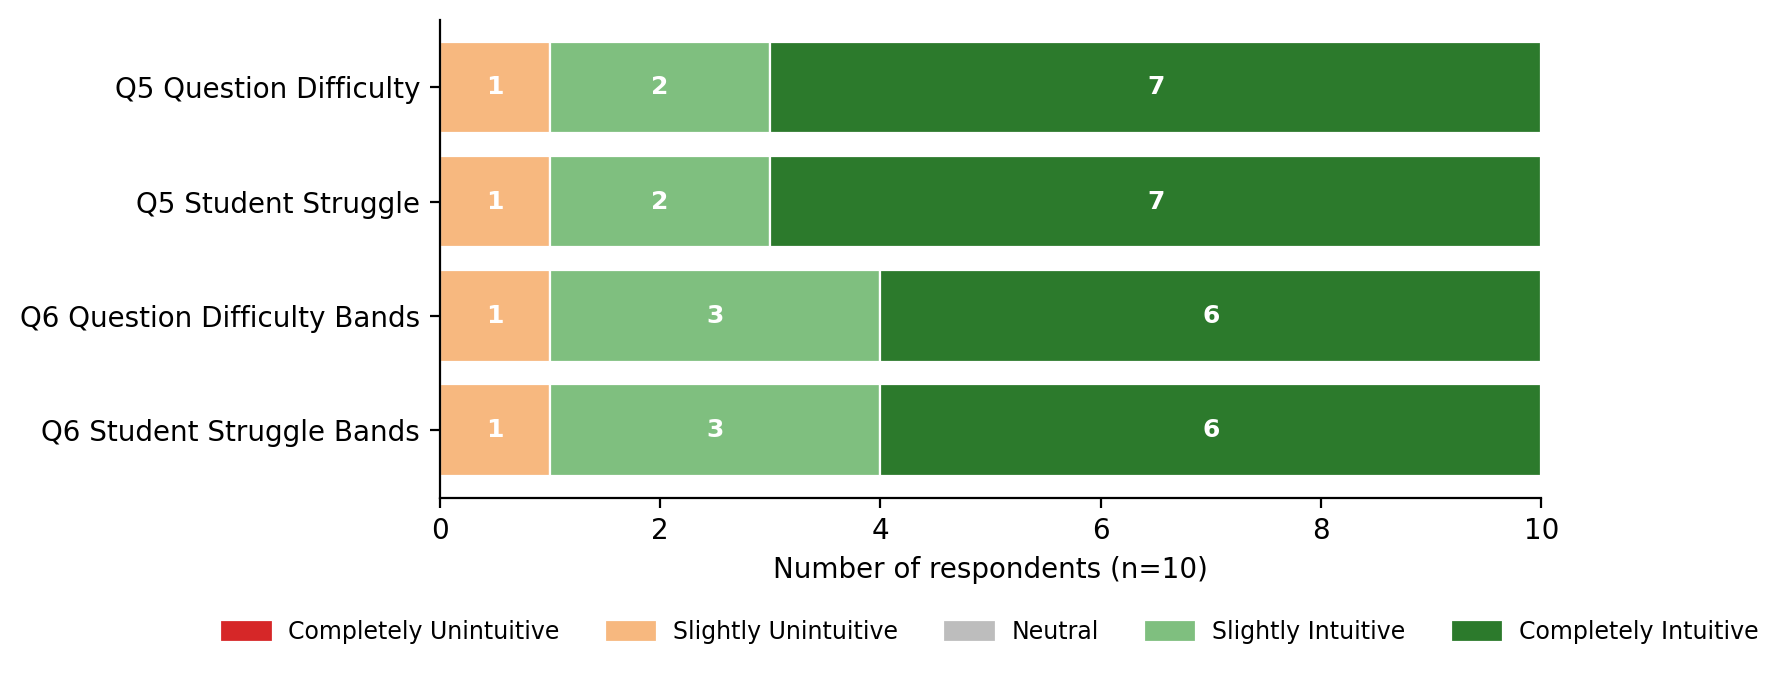

saved c:\Users\Bakri\OneDrive - Loughborough University\Masters Year\Thesis\Dashboard v3\Report\figures\evaluation\eval-survey-clarity-intuitiveness.png


In [8]:
intuit_rows = [
    ("Q5 Question Difficulty", list(Q5_DIFFICULTY.values())),
    ("Q5 Student Struggle", list(Q5_STRUGGLE.values())),
    ("Q6 Question Difficulty Bands", list(Q6_DIFFICULTY_BANDS.values())),
    ("Q6 Student Struggle Bands", list(Q6_STRUGGLE_BANDS.values())),
]

fig, ax = plt.subplots(figsize=(8.5, 3.6), dpi=200)
for i, (label, vals) in enumerate(intuit_rows):
    left = 0
    for v, colour in zip(vals, DIVERGING_PALETTE[::-1]):  # reverse so CI is positive (green)
        if v == 0:
            left += v
            continue
        ax.barh(i, v, left=left, color=colour, edgecolor="white", linewidth=0.8)
        if v >= 1:
            ax.text(left + v / 2, i, str(v), ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
        left += v

ax.set_yticks(range(len(intuit_rows)))
ax.set_yticklabels([r[0] for r in intuit_rows])
ax.invert_yaxis()
ax.set_xlim(0, N)
ax.set_xlabel(f"Number of respondents (n={N})")
ax.spines[["top", "right"]].set_visible(False)

legend_labels = INTUITIVENESS_ORDER
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in DIVERGING_PALETTE[::-1]]
ax.legend(legend_handles, legend_labels, loc="lower center", bbox_to_anchor=(0.5, -0.35),
          ncol=5, frameon=False, fontsize=8.5)

plt.tight_layout()
out = FIG_DIR / "eval-survey-clarity-intuitiveness.png"
plt.savefig(out, bbox_inches="tight")
plt.show()
print(f"saved {out}")

## Save canonical summary JSON

Mirrors how `data/eval/results.md` works for the v2 refit — gives the writing chat a single file to lift numbers from.

In [9]:
summary = {
    "n_respondents": N,
    "likert": {
        "Q1_demographics": Q1,
        "Q2_timely_help": Q2,
        "Q3_identify_strugglers": Q3,
        "Q7_trust": Q7,
        "Q9_comfort": Q9,
    },
    "matrix": {
        "Q5_clarity": {
            "Student Struggle": Q5_STRUGGLE,
            "Question Difficulty": Q5_DIFFICULTY,
        },
        "Q6_band_intuitiveness": {
            "Student Struggle Bands": Q6_STRUGGLE_BANDS,
            "Question Difficulty Bands": Q6_DIFFICULTY_BANDS,
        },
    },
    "matrix_persistent_dissenters": n_same_dissenter,
    "freetext": freetext_summary,
    "figures": [
        "Report/figures/evaluation/eval-survey-likert.png",
        "Report/figures/evaluation/eval-survey-clarity-intuitiveness.png",
    ],
}

SUMMARY_PATH.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"saved {SUMMARY_PATH}")
print(json.dumps(summary, indent=2, ensure_ascii=False)[:2000])

saved c:\Users\Bakri\OneDrive - Loughborough University\Masters Year\Thesis\Dashboard v3\data\eval\survey_summary.json
{
  "n_respondents": 10,
  "likert": {
    "Q1_demographics": {
      "Undergraduate Student": 6,
      "Postgraduate Taught Student": 1,
      "Postgraduate Research Student": 2,
      "Staff": 1,
      "Other": 0
    },
    "Q2_timely_help": {
      "Always": 1,
      "Often": 4,
      "Sometimes": 4,
      "Rarely": 1,
      "Never": 0
    },
    "Q3_identify_strugglers": {
      "Extremely easy": 0,
      "Somewhat easy": 2,
      "Neutral": 2,
      "Somewhat not easy": 4,
      "Extremely not easy": 2
    },
    "Q7_trust": {
      "Very likely": 2,
      "Somewhat likely": 5,
      "Neither likely nor unlikely": 1,
      "Somewhat unlikely": 1,
      "Very unlikely": 1
    },
    "Q9_comfort": {
      "Very comfortable": 3,
      "Somewhat comfortable": 3,
      "Neither comfortable nor uncomfortable": 1,
      "Somewhat uncomfortable": 3,
      "Very uncomforta